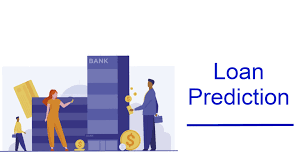

Loan Application Predictor:

The objective of this project is to develop a loan application system that allows borrowers to submit their loan requests along with key financial details. The system aims to facilitate efficient and accurate assessment of a borrower’s eligibility, enabling lenders to make informed decisions regarding the approval of funds or credit.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [10]:
# Reading the loan_train.csv file
loan_data = pd.read_csv("https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv",index_col=False)

# Removing the column named 'Unnamed: 0' from the loan_data dataframe using the drop() method
loan_data = loan_data.drop(['Unnamed: 0'], axis=1)

# Displaying the first few rows of the loan_data dataframe using the head() method
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [11]:
test_data = pd.read_csv('https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_test.csv')
test_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001116,Male,No,0,Not Graduate,No,3748,1668.0,110.0,360.0,1.0,Semiurban
1,LP001488,Male,Yes,3+,Graduate,No,4000,7750.0,290.0,360.0,1.0,Semiurban
2,LP002138,Male,Yes,0,Graduate,No,2625,6250.0,187.0,360.0,1.0,Rural
3,LP002284,Male,No,0,Not Graduate,No,3902,1666.0,109.0,360.0,1.0,Rural
4,LP002328,Male,Yes,0,Not Graduate,No,6096,0.0,218.0,360.0,0.0,Rural


In [12]:
loan_data.shape

(491, 13)

In [13]:
test_data.shape

(123, 12)

In [14]:
loan_data['Loan_Status'].value_counts()

,count
Loan_Status,
1,343
0,148


In [15]:
loan_data['Loan_Status'].value_counts(normalize=True)

,proportion
Loan_Status,
1,0.698574
0,0.301426


<Axes: xlabel='Loan_Status'>

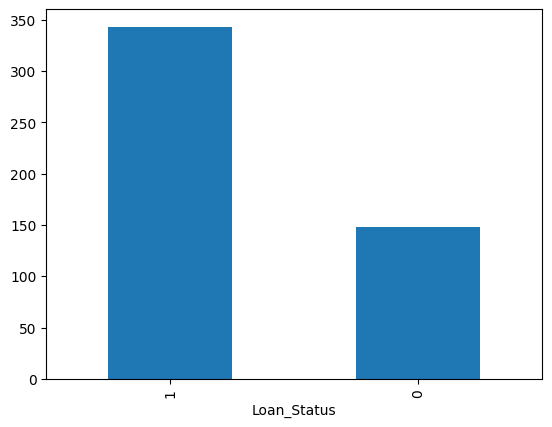

In [16]:
loan_data['Loan_Status'].value_counts().plot.bar()

Independent Variable (Categorical)

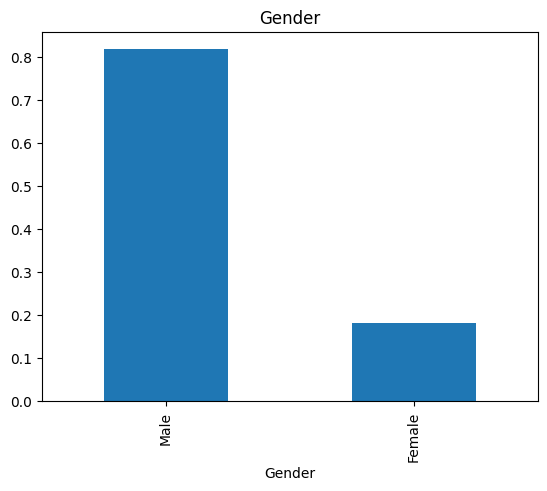

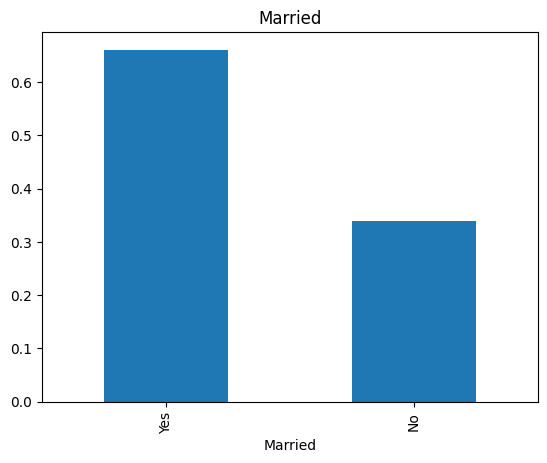

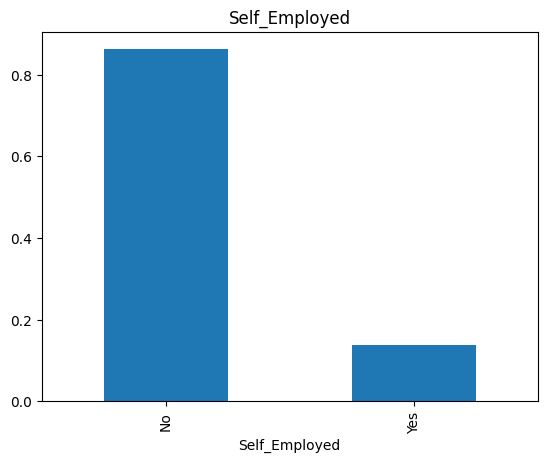

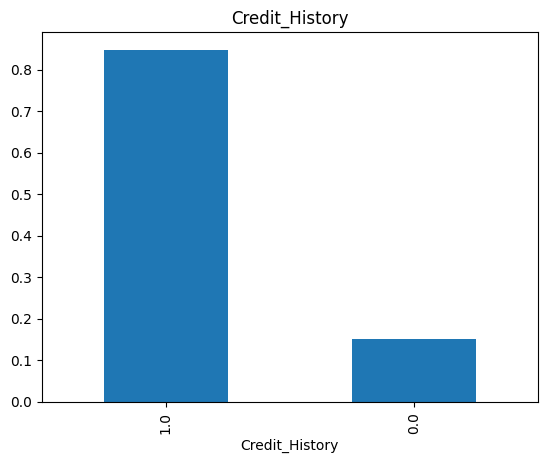

In [17]:
loan_data['Gender'].value_counts(normalize=True).plot.bar(title='Gender')
plt.show()
loan_data['Married'].value_counts(normalize=True).plot.bar(title='Married')
plt.show()
loan_data['Self_Employed'].value_counts(normalize=True).plot.bar(title='Self_Employed')
plt.show()
loan_data['Credit_History'].value_counts(normalize=True).plot.bar(title='Credit_History')
plt.show()

Independent Variable (Ordinal)

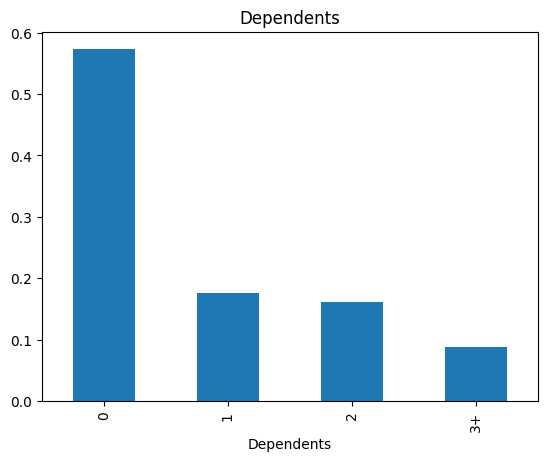

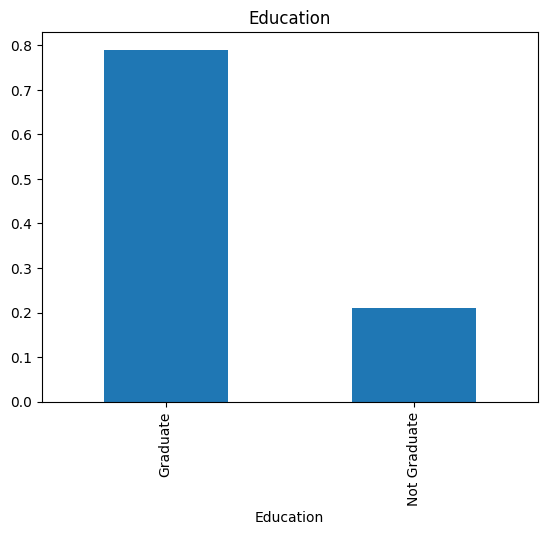

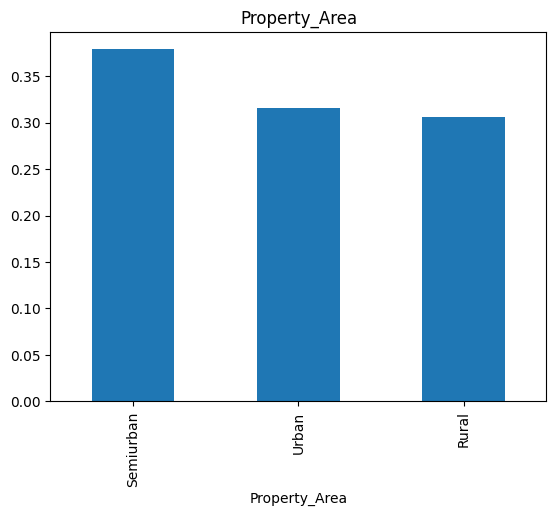

In [18]:
loan_data['Dependents'].value_counts(normalize=True).plot.bar( title='Dependents')
plt.show()
loan_data['Education'].value_counts(normalize=True).plot.bar(title='Education')
plt.show()
loan_data['Property_Area'].value_counts(normalize=True).plot.bar(title='Property_Area')
plt.show()

Independent Variable (Numerical)

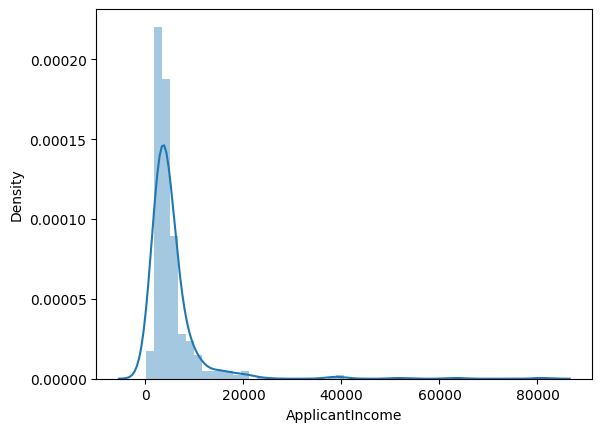

In [19]:
sns.distplot(loan_data['ApplicantIncome'])
plt.show()

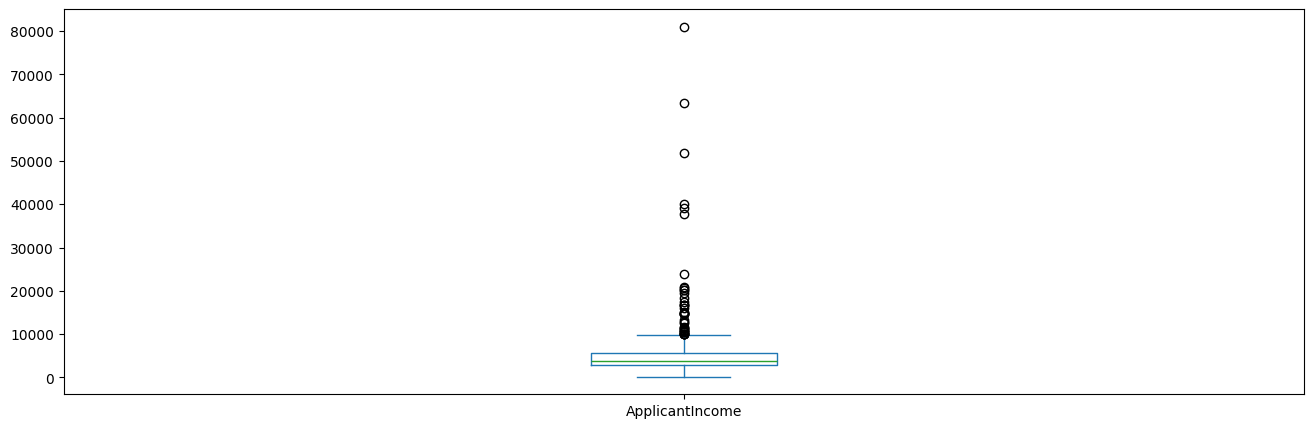

In [20]:
loan_data['ApplicantIncome'].plot.box(figsize=(16,5))
plt.show()

Text(0.5, 0.98, '')

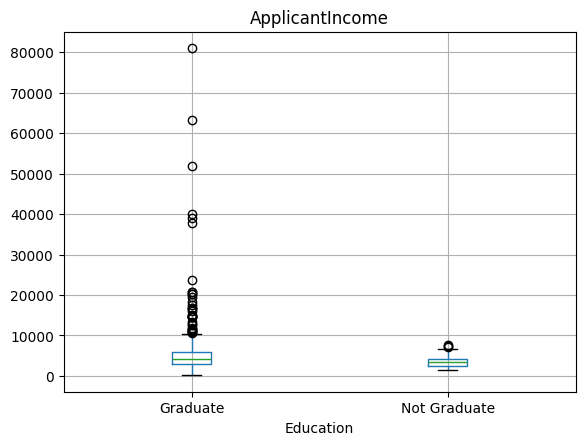

In [21]:
loan_data.boxplot(column='ApplicantIncome', by='Education')
plt.suptitle("")

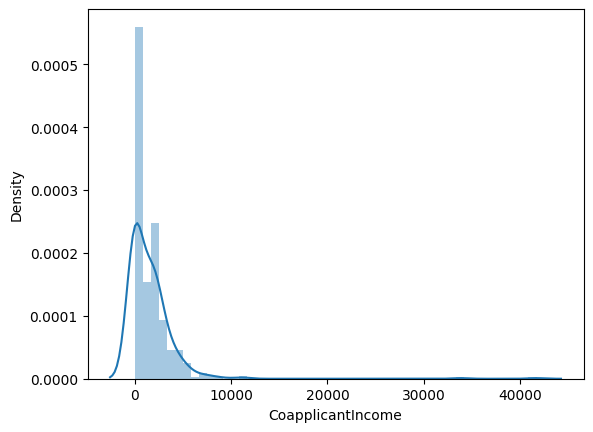

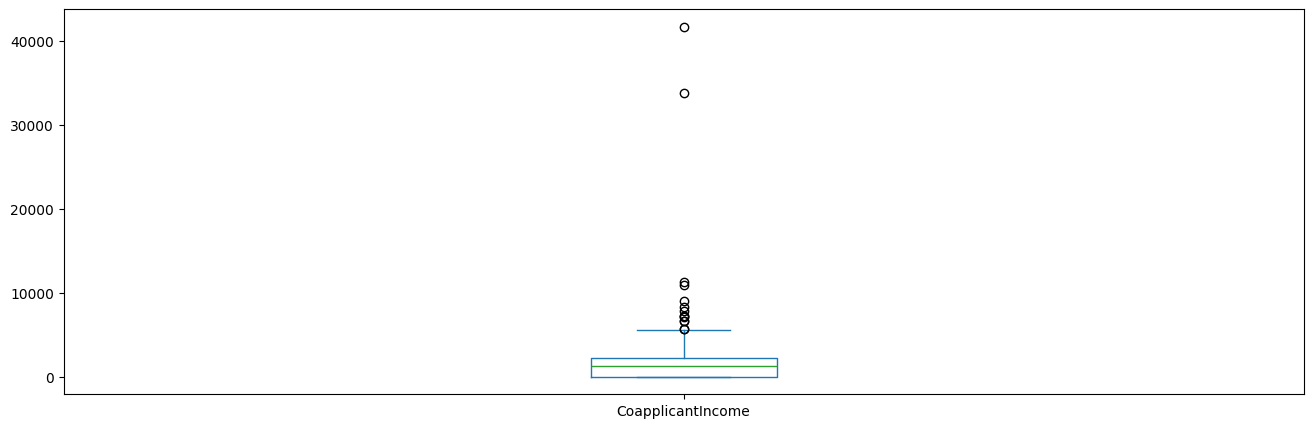

In [22]:
sns.distplot(loan_data['CoapplicantIncome'])
plt.show()
loan_data['CoapplicantIncome'].plot.box(figsize=(16,5))
plt.show()

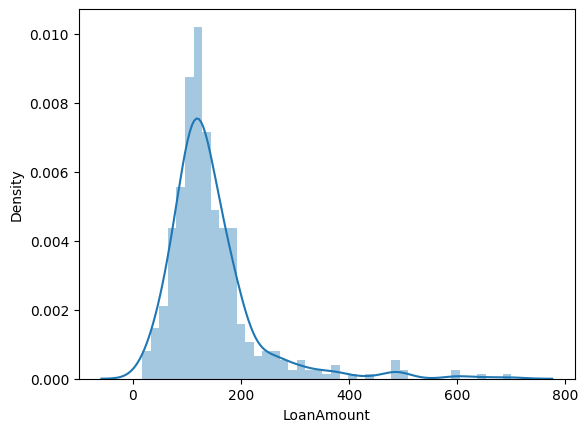

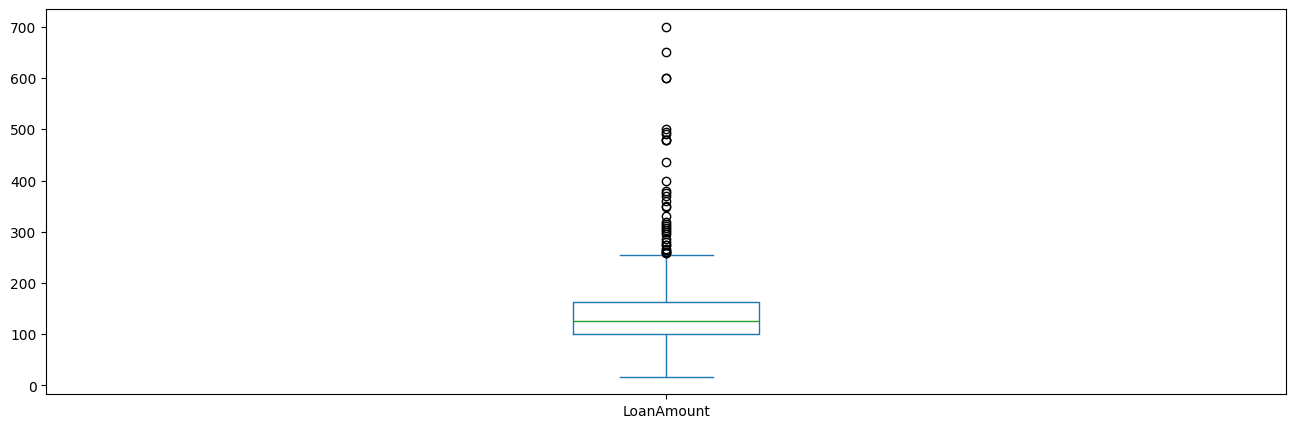

In [23]:
loan_data.notna()

sns.distplot(loan_data['LoanAmount'])
plt.show()
loan_data['LoanAmount'].plot.box(figsize=(16,5))
plt.show()

Bivariate Analysis,

Categorical Independent Variable vs Target Variable

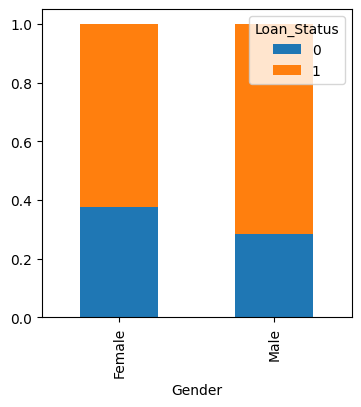

In [24]:
Gender = pd.crosstab(loan_data['Gender'], loan_data['Loan_Status'])

Gender.div(Gender.sum(axis=1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()

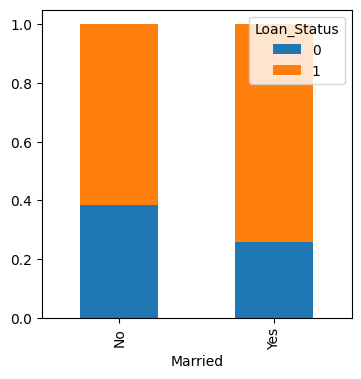

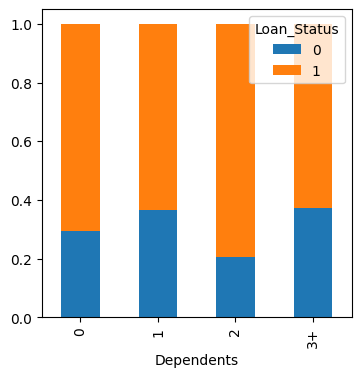

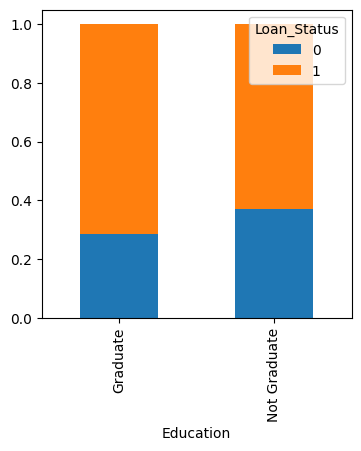

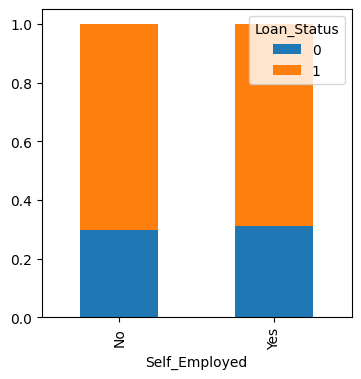

In [25]:
Married = pd.crosstab(loan_data['Married'], loan_data['Loan_Status'])
Dependents = pd.crosstab(loan_data['Dependents'], loan_data['Loan_Status'])
Education = pd.crosstab(loan_data['Education'], loan_data['Loan_Status'])
Self_Employed = pd.crosstab(loan_data['Self_Employed'], loan_data['Loan_Status'])

Married.div(Married.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Dependents.div(Dependents.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()

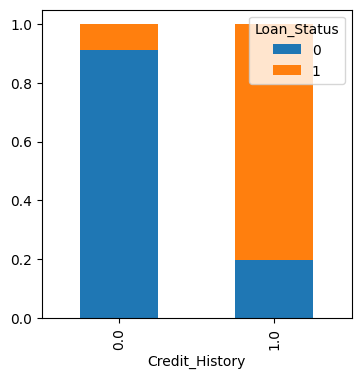

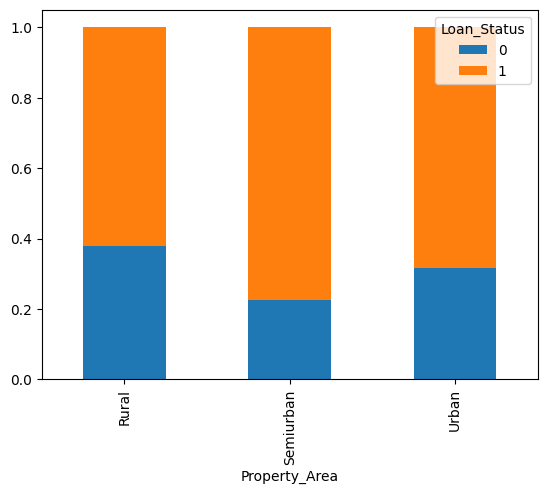

In [26]:
Credit_History=pd.crosstab(loan_data['Credit_History'],loan_data['Loan_Status'])
Property_Area=pd.crosstab(loan_data['Property_Area'],loan_data['Loan_Status'])
Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind="bar",stacked=True,figsize=(4,4))
plt.show()
Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind="bar",stacked=True)
plt.show()

Numerical Independent Variable vs Target Variable

<Axes: xlabel='Loan_Status'>

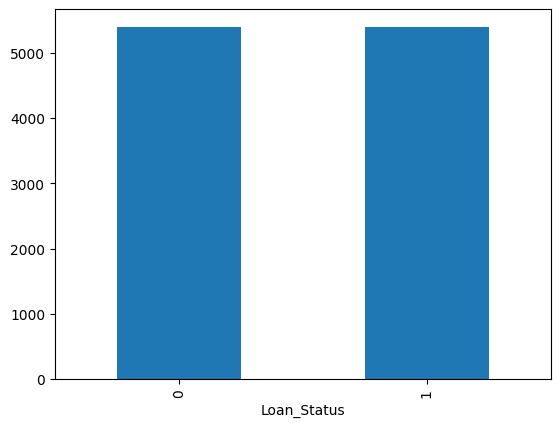

In [27]:
loan_data.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()

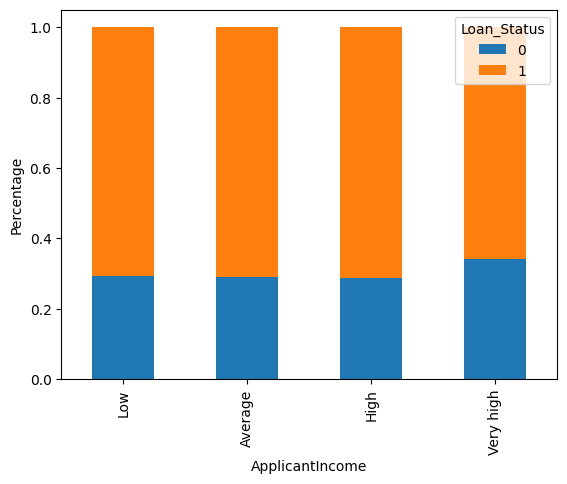

In [28]:
bins=[0,2500,4000,6000,81000]
group=['Low','Average','High','Very high']
loan_data['Income_bin']=pd.cut(loan_data['ApplicantIncome'],bins,labels=group)
Income_bin=pd.crosstab(loan_data['Income_bin'],loan_data['Loan_Status'])
Income_bin.div(Income_bin.sum(1).astype(float), axis=0).plot(kind="bar",stacked=True)
plt.xlabel('ApplicantIncome')
P=plt.ylabel('Percentage')

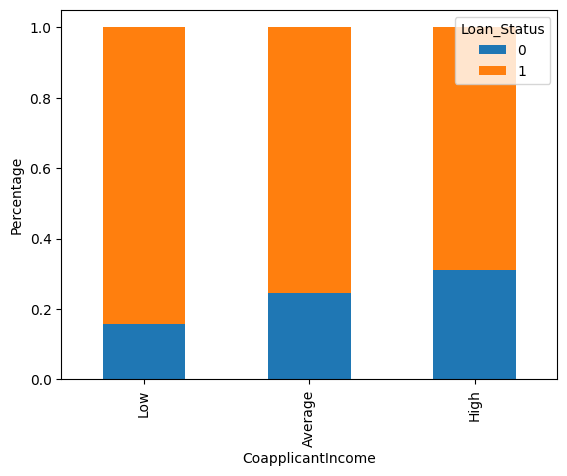

In [29]:
bins=[0,1000,3000,42000]
group=['Low','Average','High']
loan_data['Coapplicant_Income_bin']=pd.cut(loan_data['CoapplicantIncome'],bins,labels=group)
Coapplicant_Income_bin=pd.crosstab(loan_data['Coapplicant_Income_bin'],loan_data['Loan_Status'])
Coapplicant_Income_bin.div(Coapplicant_Income_bin.sum(1).astype(float), axis=0).plot(kind="bar",stacked=True)
plt.xlabel('CoapplicantIncome')
P=plt.ylabel('Percentage')

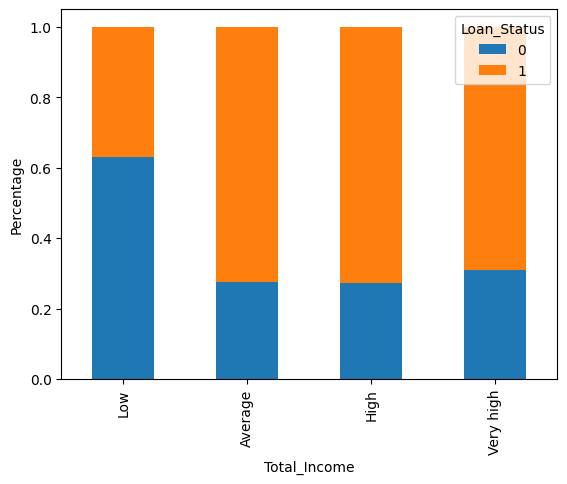

In [30]:
loan_data['Total_Income']=loan_data['ApplicantIncome']+loan_data['CoapplicantIncome']
bins=[0,2500,4000,6000,81000]
group=['Low','Average','High','Very high']
loan_data['Total_Income_bin']=pd.cut(loan_data['Total_Income'],bins,labels=group)
Total_Income_bin=pd.crosstab(loan_data['Total_Income_bin'],loan_data['Loan_Status'])
Total_Income_bin.div(Total_Income_bin.sum(1).astype(float), axis=0).plot(kind="bar",stacked=True)
plt.xlabel('Total_Income')
P=plt.ylabel('Percentage')

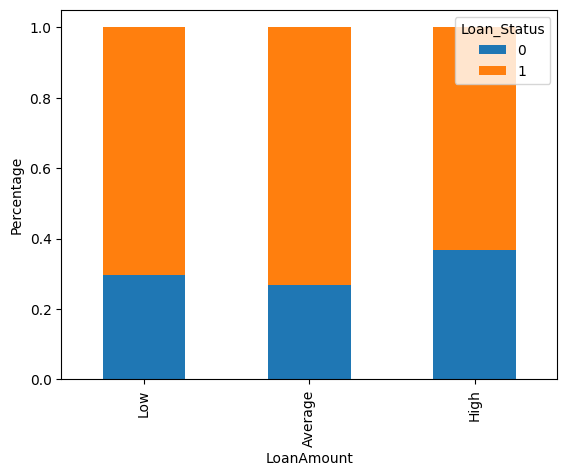

In [31]:
bins=[0,100,200,700]
group=['Low','Average','High']
loan_data['LoanAmount_bin']=pd.cut(loan_data['LoanAmount'],bins,labels=group)
LoanAmount_bin=pd.crosstab(loan_data['LoanAmount_bin'],loan_data['Loan_Status'])
LoanAmount_bin.div(LoanAmount_bin.sum(1).astype(float), axis=0).plot(kind="bar",stacked=True)
plt.xlabel('LoanAmount')
P=plt.ylabel('Percentage')

In [32]:
# print(train.dtypes)
loan_data=loan_data.drop(['Income_bin', 'Coapplicant_Income_bin', 'LoanAmount_bin', 'Total_Income_bin', 'Total_Income'], axis=1)
loan_data['Dependents'].replace('3+', 3,inplace=True)
test_data['Dependents'].replace('3+', 3,inplace=True)

Missing value imputation

In [33]:
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,10
Married,1
Dependents,9
Education,0
Self_Employed,29
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,16
Loan_Amount_Term,13


There are very less missing values in Gender, Married, Dependents, Credit_History and Self_Employed features so we can fill them using the mode of the features.

In [34]:
loan_data['Gender'].fillna(loan_data['Gender'].mode()[0], inplace=True)
loan_data['Married'].fillna(loan_data['Married'].mode()[0], inplace=True)
loan_data['Dependents'].fillna(loan_data['Dependents'].mode()[0], inplace=True)
loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0], inplace=True)
loan_data['Credit_History'].fillna(loan_data['Credit_History'].mode()[0], inplace=True)

In [35]:
loan_data['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,404
180.0,35
480.0,13
300.0,12
84.0,4
240.0,3
120.0,3
36.0,2
12.0,1


In [36]:
loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mode()[0], inplace=True)

In [37]:
loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median(), inplace=True)

In [38]:
loan_data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [39]:
test_data['Gender'].fillna(loan_data['Gender'].mode()[0], inplace=True)
test_data['Married'].fillna(loan_data['Married'].mode()[0], inplace=True)
test_data['Dependents'].fillna(loan_data['Dependents'].mode()[0], inplace=True)
test_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0], inplace=True)
test_data['Credit_History'].fillna(loan_data['Credit_History'].mode()[0], inplace=True)
test_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].mode()[0], inplace=True)
test_data['LoanAmount'].fillna(loan_data['LoanAmount'].median(), inplace=True)

Outlier Treatement

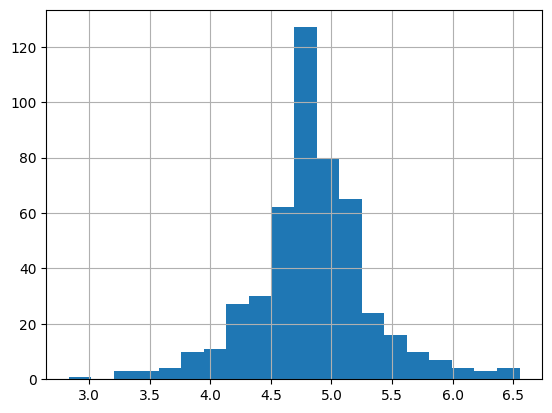

In [40]:
loan_data['LoanAmount_log']=np.log(loan_data['LoanAmount'])
loan_data['LoanAmount_log'].hist(bins=20)
test_data['LoanAmount_log']=np.log(test_data['LoanAmount'])

Model Building

Part I

Logistic Regression

In [41]:
loan_data=loan_data.drop('Loan_ID',axis=1)
test_data=test_data.drop('Loan_ID',axis=1)

In [42]:
X = loan_data.drop('Loan_Status',axis=1)
y = loan_data.Loan_Status

In [43]:
train = loan_data.copy()
test = test_data.copy()

In [44]:
X = pd.get_dummies(X)
train=pd.get_dummies(train)
test=pd.get_dummies(test)

In [45]:
from sklearn.model_selection import train_test_split
x_train, x_valid, y_train, y_valid = train_test_split(X,y, test_size=0.3)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [47]:
pred_cv = model.predict(x_valid)
print('Model Accuracy = ', accuracy_score(y_valid,pred_cv))
print('Model F1-Score = ', f1_score(y_valid,pred_cv))

Model Accuracy =  0.8040540540540541
Model F1-Score =  0.8733624454148472


In [48]:
pred_test = model.predict(test)

Logistic Regression using stratified k-folds cross validation

In [49]:
from sklearn.model_selection import StratifiedKFold

In [50]:
i=1
mean = 0
fmean = 0
kf = StratifiedKFold(n_splits=5)
for train_index,test_index in kf.split(X,y):
    print ('\n{} of kfold {} '.format(i,kf.n_splits))
    xtr,xvl = X.loc[train_index],X.loc[test_index]
    ytr,yvl = y[train_index],y[test_index]
    model = LogisticRegression(random_state=1)
    model.fit(xtr,ytr)
    pred_test=model.predict(xvl)
    score=accuracy_score(yvl,pred_test)
    f1score = f1_score(yvl,pred_test)
    mean += score
    fmean += f1score
    print('#######################')
    print ('accuracy_score',score)
    print('-------------------------')
    print ('F1 Score ',f1score)
    print('#######################')
    i+=1
    pred_test_f = model.predict(test)
    pred = model.predict_proba(xvl)[:,1]

print('----------- Final Mean Score---------------')
print('###########################################')
print ('\n Mean Validation Accuracy',mean/(i-1))
print ('\n Mean Validation F1 Score',fmean/(i-1))
print('###########################################')
print('-------------------------------------------')


1 of kfold 5 
#######################
accuracy_score 0.8181818181818182
-------------------------
F1 Score  0.881578947368421
#######################

2 of kfold 5 
#######################
accuracy_score 0.7551020408163265
-------------------------
F1 Score  0.8356164383561644
#######################

3 of kfold 5 
#######################
accuracy_score 0.7551020408163265
-------------------------
F1 Score  0.85
#######################

4 of kfold 5 
#######################
accuracy_score 0.8367346938775511
-------------------------
F1 Score  0.8840579710144928
#######################

5 of kfold 5 
#######################
accuracy_score 0.7959183673469388
-------------------------
F1 Score  0.868421052631579
#######################
----------- Final Mean Score---------------
###########################################

 Mean Validation Accuracy 0.7922077922077921

 Mean Validation F1 Score 0.8639348818741315
###########################################
--------------------------------

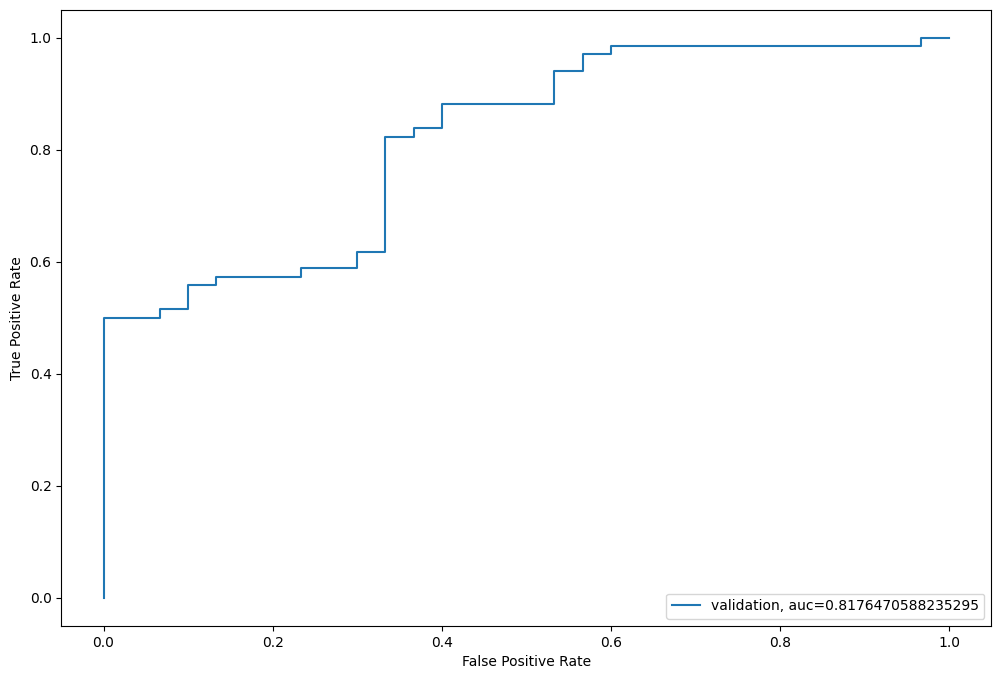

In [51]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(yvl, pred)
auc = metrics.roc_auc_score(yvl, pred)
plt.figure(figsize=(12,8))
plt.plot(fpr, tpr, label="validation, auc="+str(auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()

Feature Engineering

In [52]:
train['Total_Income']=train['ApplicantIncome']+train['CoapplicantIncome']
test['Total_Income']=test['ApplicantIncome']+test['CoapplicantIncome']

<Axes: xlabel='Total_Income', ylabel='Density'>

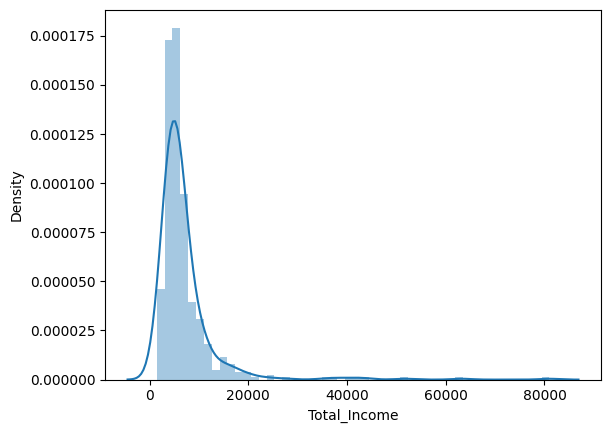

In [53]:
sns.distplot(train['Total_Income'])

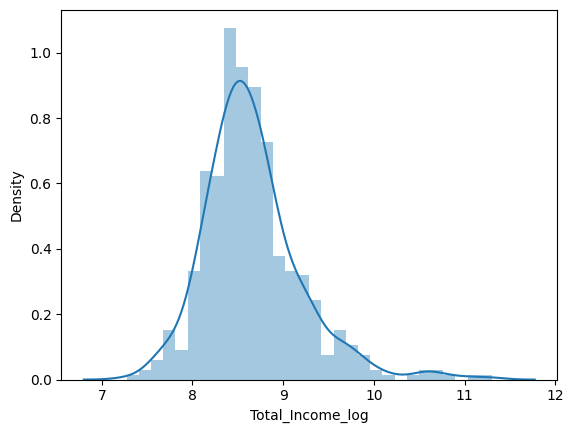

In [54]:
train['Total_Income_log'] = np.log(train['Total_Income'])
sns.distplot(train['Total_Income_log'])
test['Total_Income_log'] = np.log(test['Total_Income'])

In [55]:
train['EMI']=train['LoanAmount']/train['Loan_Amount_Term']
test['EMI']=test['LoanAmount']/test['Loan_Amount_Term']

<Axes: xlabel='EMI', ylabel='Density'>

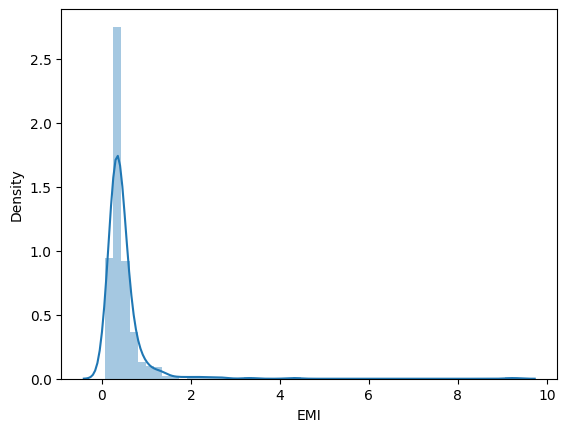

In [56]:
sns.distplot(train['EMI'])

<Axes: xlabel='Balance Income', ylabel='Density'>

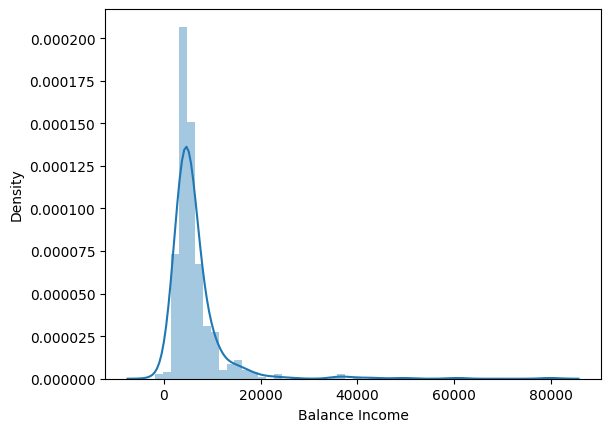

In [57]:
train['Balance Income'] = train['Total_Income']-(train['EMI']*1000)
test['Balance Income'] = test['Total_Income']-(test['EMI']*1000)
sns.distplot(train['Balance Income'])

In [58]:
train=train.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term'], axis=1)
test=test.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term'], axis=1)

Part II

In [59]:
X = train.drop('Loan_Status', axis= 1)
y = train.Loan_Status

Logistic Regression

In [60]:
i=1
mean = 0
fmean = 0
print('----------- After Features Engineering---------------')
kf = StratifiedKFold(n_splits=5)
for train_index,test_index in kf.split(X,y):
    print ('\n{} of kfold {} '.format(i,kf.n_splits))
    xtr,xvl = X.loc[train_index],X.loc[test_index]
    ytr,yvl = y[train_index],y[test_index]
    model = LogisticRegression(random_state=1)
    model.fit(xtr,ytr)
    pred_test=model.predict(xvl)
    score=accuracy_score(yvl,pred_test)
    f1score = f1_score(yvl,pred_test)
    mean += score
    fmean += f1score

    print ('accuracy_score',score)
    print('-------------------------')
    print ('F1 Score ',f1score)

    i+=1
    pred_test_fe = model.predict(test)
    pred = model.predict_proba(xvl)[:,1]


print('----------- Final Mean Score---------------')
# print('###########################################')
print ('\n Mean Validation Accuracy',mean/(i-1))
print ('\n Mean Validation F1 Score',fmean/(i-1))
# print('###########################################')
print('-------------------------------------------')

----------- After Features Engineering---------------

1 of kfold 5 
accuracy_score 0.8282828282828283
-------------------------
F1 Score  0.8888888888888888

2 of kfold 5 
accuracy_score 0.7551020408163265
-------------------------
F1 Score  0.8356164383561644

3 of kfold 5 
accuracy_score 0.7448979591836735
-------------------------
F1 Score  0.84472049689441

4 of kfold 5 
accuracy_score 0.826530612244898
-------------------------
F1 Score  0.8794326241134752

5 of kfold 5 
accuracy_score 0.7959183673469388
-------------------------
F1 Score  0.868421052631579
----------- Final Mean Score---------------

 Mean Validation Accuracy 0.790146361574933

 Mean Validation F1 Score 0.8634159001769035
-------------------------------------------


In [61]:
lr_acc = 0.790146361574933
lr_f1 = 0.8634159001769035

In [62]:
print('Logistic Regression Accuracy = ',lr_acc)
print('Logistic Regression F1-Score = ',lr_f1)

Logistic Regression Accuracy =  0.790146361574933
Logistic Regression F1-Score =  0.8634159001769035


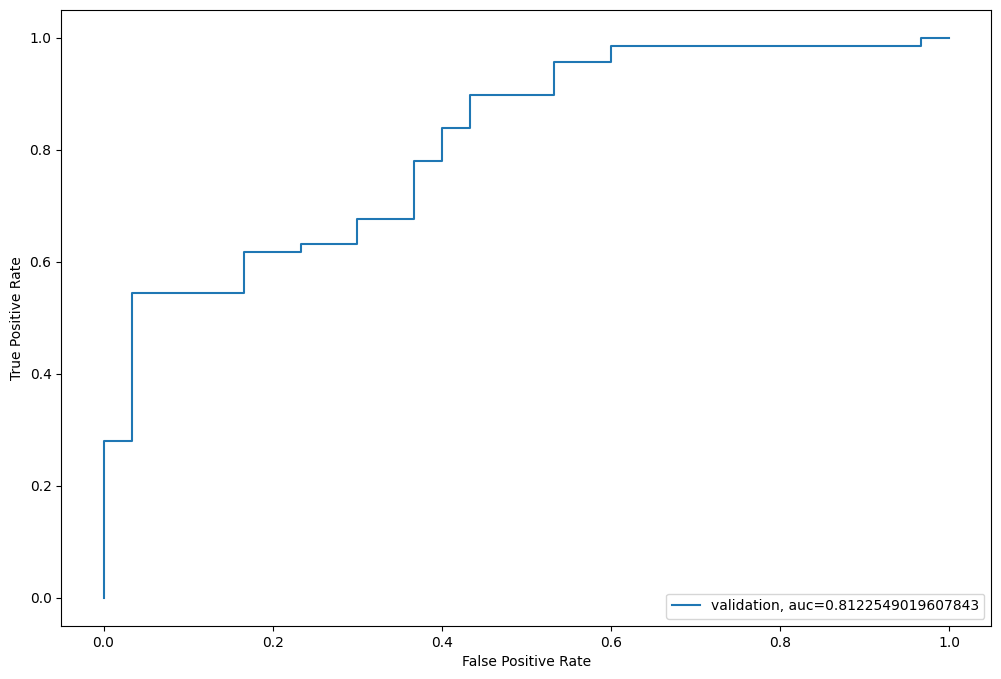

0.8122549019607843


In [63]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(yvl, pred)
auc = metrics.roc_auc_score(yvl, pred)
plt.figure(figsize=(12,8))
plt.plot(fpr, tpr, label="validation, auc="+str(auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()
print(auc)

In [64]:
lr_auc = auc

In [65]:
print(lr_auc)

0.8122549019607843


Decision Tree

In [66]:
from sklearn.tree import  DecisionTreeClassifier
i=1
mean = 0
fmean = 0
print('----------- After Features Engineering---------------')
kf = StratifiedKFold(n_splits=5)
for train_index,test_index in kf.split(X,y):
    print ('\n{} of kfold {} '.format(i,kf.n_splits))
    xtr,xvl = X.loc[train_index],X.loc[test_index]
    ytr,yvl = y[train_index],y[test_index]
    model_tree = DecisionTreeClassifier(random_state=1)
    model_tree.fit(xtr,ytr)
    pred_test=model_tree.predict(xvl)
    score=accuracy_score(yvl,pred_test)
    f1score = f1_score(yvl,pred_test)
    mean += score
    fmean += f1score
    print('#######################')
    print ('accuracy_score',score)
    print('-------------------------')
    print ('F1 Score ',f1score)
    print('#######################')
    i+=1
    pred_test_tree = model_tree.predict(test)
    pred = model_tree.predict_proba(xvl)[:,1]


print('----------- Final Mean Score---------------')
print('###########################################')
print ('\n Mean Validation Accuracy',mean/(i-1))
print ('\n Mean Validation F1 Score',fmean/(i-1))
print('###########################################')
print('-------------------------------------------')

----------- After Features Engineering---------------

1 of kfold 5 
#######################
accuracy_score 0.7575757575757576
-------------------------
F1 Score  0.8356164383561644
#######################

2 of kfold 5 
#######################
accuracy_score 0.673469387755102
-------------------------
F1 Score  0.7681159420289855
#######################

3 of kfold 5 
#######################
accuracy_score 0.673469387755102
-------------------------
F1 Score  0.7894736842105263
#######################

4 of kfold 5 
#######################
accuracy_score 0.7346938775510204
-------------------------
F1 Score  0.8
#######################

5 of kfold 5 
#######################
accuracy_score 0.7448979591836735
-------------------------
F1 Score  0.8201438848920863
#######################
----------- Final Mean Score---------------
###########################################

 Mean Validation Accuracy 0.7168212739641311

 Mean Validation F1 Score 0.8026699898975526
#######################

In [67]:
dt_acc = 0.7168212739641311
dt_f1 = 0.8026699898975526

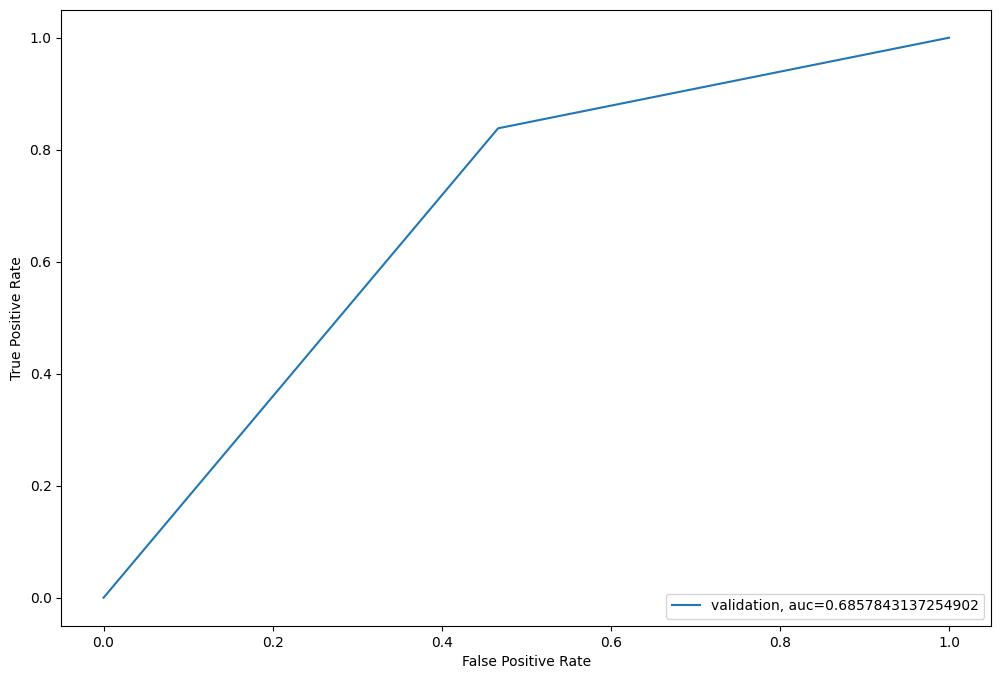

0.6857843137254902


In [68]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(yvl, pred)
auc = metrics.roc_auc_score(yvl, pred)

plt.figure(figsize=(12,8))
plt.plot(fpr, tpr, label="validation, auc="+str(auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()
print(auc)


In [69]:

dt_auc = auc

In [70]:
print(dt_auc)

0.6857843137254902


In [71]:
print(dt_f1)

0.8026699898975526


In [72]:


from sklearn.ensemble import RandomForestClassifier

In [73]:
from sklearn.model_selection import StratifiedKFold

In [74]:
from sklearn.metrics import accuracy_score, f1_score

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

i = 1
mean = 0
fmean = 0

print('----------- After Feature Engineering (Random Forest) ---------------')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    print('\n{} of kfold {}'.format(i, kf.n_splits))

    # Split data
    xtr, xvl = X.loc[train_index], X.loc[test_index]
    ytr, yvl = y[train_index], y[test_index]

    # Random Forest Model
    model_rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=1,
        n_jobs=-1
    )

    # Train
    model_rf.fit(xtr, ytr)

    # Validation Prediction
    pred_test = model_rf.predict(xvl)

    # Metrics
    score = accuracy_score(yvl, pred_test)
    f1score = f1_score(yvl, pred_test)

    mean += score
    fmean += f1score

    #print('#######################')
    print('Accuracy Score:', score)
    print('-----------------------')
    print('F1 Score:', f1score)
    #print('#######################')

    # Test set prediction (for submission / final inference)
    pred_test_rf = model_rf.predict(test)
    pred_proba_rf = model_rf.predict_proba(xvl)[:, 1]

    i += 1

print('----------- Final Mean Score (Random Forest) ---------------')
print('###########################################')
print('Mean Validation Accuracy:', mean / (i - 1))
print('Mean Validation F1 Score:', fmean / (i - 1))
print('###########################################')
print('-------------------------------------------')


----------- After Feature Engineering (Random Forest) ---------------

1 of kfold 5
Accuracy Score: 0.7676767676767676
-----------------------
F1 Score: 0.8456375838926175

2 of kfold 5
Accuracy Score: 0.8367346938775511
-----------------------
F1 Score: 0.8888888888888888

3 of kfold 5
Accuracy Score: 0.7448979591836735
-----------------------
F1 Score: 0.8344370860927153

4 of kfold 5
Accuracy Score: 0.7857142857142857
-----------------------
F1 Score: 0.8551724137931035

5 of kfold 5
Accuracy Score: 0.7857142857142857
-----------------------
F1 Score: 0.8609271523178808
----------- Final Mean Score (Random Forest) ---------------
###########################################
Mean Validation Accuracy: 0.7841475984333126
Mean Validation F1 Score: 0.8570126249970411
###########################################
-------------------------------------------


In [76]:
rf_acc = 0.7841475984333126
rf_f1 = 0.8570126249970411

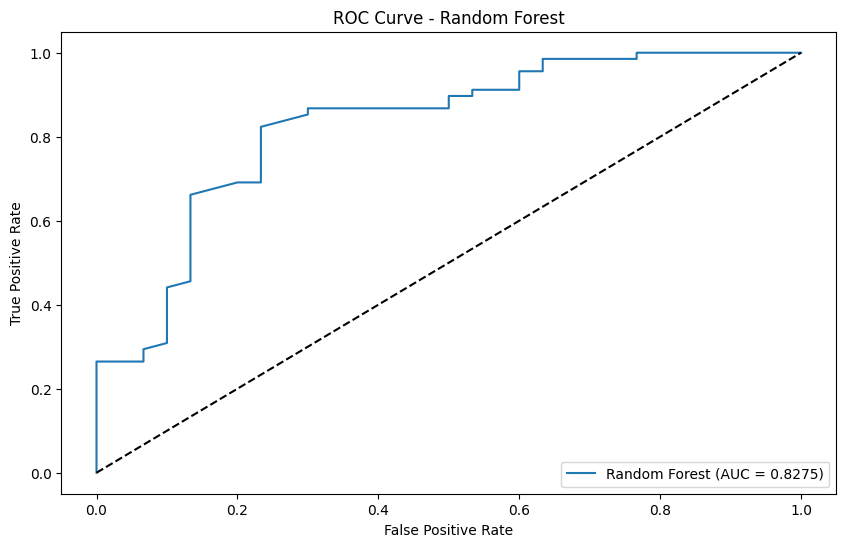

0.8274509803921569


In [77]:
fpr_rf, tpr_rf, _ = metrics.roc_curve(yvl, pred_proba_rf)
auc_rf = metrics.roc_auc_score(yvl, pred_proba_rf)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = {:.4f})".format(auc_rf))
plt.plot([0, 1], [0, 1], 'k--')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc=4)
plt.show()
print(auc_rf)

In [78]:
rf_auc = 0.8274509803921569

In [79]:
!pip install xgboost

In [80]:
from xgboost import XGBClassifier

In [81]:
i = 1
mean = 0
fmean = 0

print('----------- After Feature Engineering (XGBoost) ---------------')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X, y):
    print('\n{} of kfold {}'.format(i, kf.n_splits))

    # Split data
    xtr, xvl = X.loc[train_index], X.loc[test_index]
    ytr, yvl = y[train_index], y[test_index]

    # XGBoost Model
    model_xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=1,
        n_jobs=-1
    )

    # Train
    model_xgb.fit(xtr, ytr)

    # Validation Prediction
    pred_test = model_xgb.predict(xvl)

    # Metrics
    score = accuracy_score(yvl, pred_test)
    f1score = f1_score(yvl, pred_test)

    mean += score
    fmean += f1score

    print('#######################')
    print('Accuracy Score:', score)
    print('-----------------------')
    print('F1 Score:', f1score)
    print('#######################')

    # Test set prediction
    pred_test_xgb = model_xgb.predict(test)
    pred_proba_xgb = model_xgb.predict_proba(xvl)[:, 1]

    i += 1

print('----------- Final Mean Score (XGBoost) ---------------')
print('###########################################')
print('Mean Validation Accuracy:', mean / (i - 1))
print('Mean Validation F1 Score:', fmean / (i - 1))
print('###########################################')
print('-------------------------------------------')


----------- After Feature Engineering (XGBoost) ---------------

1 of kfold 5
#######################
Accuracy Score: 0.7474747474747475
-----------------------
F1 Score: 0.8299319727891157
#######################

2 of kfold 5
#######################
Accuracy Score: 0.8367346938775511
-----------------------
F1 Score: 0.8904109589041096
#######################

3 of kfold 5
#######################
Accuracy Score: 0.7244897959183674
-----------------------
F1 Score: 0.8163265306122449
#######################

4 of kfold 5
#######################
Accuracy Score: 0.7857142857142857
-----------------------
F1 Score: 0.8551724137931035
#######################

5 of kfold 5
#######################
Accuracy Score: 0.8061224489795918
-----------------------
F1 Score: 0.8707482993197279
#######################
----------- Final Mean Score (XGBoost) ---------------
###########################################
Mean Validation Accuracy: 0.7801071943929088
Mean Validation F1 Score: 0.85251803508366

In [82]:
xgb_acc = 0.7801071943929088
xgb_f1 = 0.8525180350836603

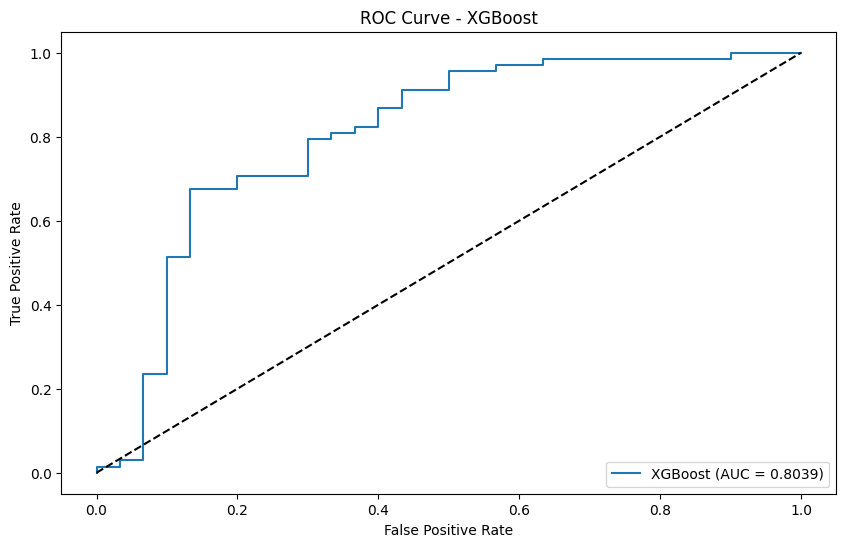

0.803921568627451


In [83]:
fpr_xgb, tpr_xgb, _ = metrics.roc_curve(yvl, pred_proba_xgb)
auc_xgb = metrics.roc_auc_score(yvl, pred_proba_xgb)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = {:.4f})".format(auc_xgb))
plt.plot([0, 1], [0, 1], 'k--')  # random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc=4)
plt.show()
print(auc_xgb)

In [84]:
xgb_auc = 0.803921568627451

In [85]:
print(xgb_acc)
print(xgb_f1)
print(xgb_auc)

0.7801071943929088
0.8525180350836603
0.803921568627451


In [86]:

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        rf_acc,
        xgb_acc
    ],
    "F1-score": [
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc,
        xgb_auc
    ]
})

comparison_df


,Model,Accuracy,F1-score,ROC-AUC
0,Logistic Regression,0.790146,0.863416,0.812255
1,Decision Tree,0.716821,0.802670,0.685784
2,Random Forest,0.784148,0.857013,0.827451
3,XGBoost,0.780107,0.852518,0.803922


In [87]:
comparison_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,F1-score,ROC-AUC
2,Random Forest,0.784148,0.857013,0.827451
0,Logistic Regression,0.790146,0.863416,0.812255
3,XGBoost,0.780107,0.852518,0.803922
1,Decision Tree,0.716821,0.802670,0.685784


✅ BEST OVERALL: Logistic Regression


Metric wise winners:

Highest Accuracy → Logistic Regression (0.7901)

Highest F1-score → Logistic Regression (0.8634)

Highest ROC-AUC → Random Forest (0.8275)

🎯 Final Decision Logic

F1-score balances Precision + Recall

In loan approval, Recall is critical (don’t reject good customers)

Logistic Regression has:

Best F1-score

Best Accuracy

Strong ROC-AUC

✅ Hence, Logistic Regression is the best model for this dataset


Compared Logistic Regression, Decision Tree, Random Forest, and XGBoost using Accuracy, F1-score, and ROC-AUC. Selected Logistic Regression as the final model due to superior F1-score and balanced performance.

# Modal Saving

In [88]:
X = loan_data.drop('Loan_Status', axis=1)
y = loan_data['Loan_Status']

In [91]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype(str)


In [92]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)


In [93]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])


In [94]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Gender', 'Married',
                                                   'ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'LoanAmount_log']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Dependents', 'Education',
                                                   'Self_Employed',
                                                   'Property_Area'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [95]:
import joblib


In [96]:
joblib.dump(pipeline, "loan_prediction_pipeline.pkl")

['loan_prediction_pipeline.pkl']

In [97]:
loaded_pipeline = joblib.load("loan_prediction_pipeline.pkl")

In [99]:
loaded_pipeline.predict(X.iloc[:1])

array([1])

**Modal is Ready for Deployment!!**